In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import add_remaining_useful_life, add_rolling_features
from train_lstm import prepare_sequences
from train_transformer import create_transformer_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("✓ All modules loaded!")
print("✓ Ready to train Transformer model with Attention!")

I0000 00:00:1777296722.721584   11993 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777296722.819215   11993 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777296725.773371   11993 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✓ All modules loaded!
✓ Ready to train Transformer model with Attention!


In [2]:
# Load and prepare data
columns = ['unit', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

train_raw = pd.read_csv('../data/train_FD001.txt', sep=' ', header=None)
train_raw.drop(train_raw.columns[[26, 27]], axis=1, inplace=True)
train_raw.columns = columns

# Add RUL
train_data = add_remaining_useful_life(train_raw)

# Add rolling features
important_sensors = ['sensor2', 'sensor3', 'sensor4', 'sensor7', 
                     'sensor11', 'sensor12', 'sensor15', 'sensor20']
train_data = add_rolling_features(train_data, important_sensors, window=5)

# Select features
feature_cols = [col for col in train_data.columns 
                if col.startswith('sensor') or 'rolling' in col]

# Normalize
scaler = MinMaxScaler()
train_data[feature_cols] = scaler.fit_transform(train_data[feature_cols])

print(f"✓ Data prepared: {train_data.shape}")
print(f"✓ Features: {len(feature_cols)}")

# Create sequences
sequence_length = 30
X_train, y_train = prepare_sequences(train_data, sequence_length)

# Split train/validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\n✓ Training set: {X_train_split.shape[0]} samples")
print(f"✓ Validation set: {X_val.shape[0]} samples")
print(f"✓ Sequence shape: {X_train.shape}")

✓ Data prepared: (20631, 43)
✓ Features: 37

✓ Training set: 14104 samples
✓ Validation set: 3527 samples
✓ Sequence shape: (17631, 30, 37)


In [3]:
import time

# Create Transformer model
model_transformer = create_transformer_model(
    sequence_length=sequence_length,
    n_features=X_train.shape[2],
    num_heads=4  # 4 attention heads
)

print("="*50)
print("TRANSFORMER MODEL ARCHITECTURE")
print("="*50)
model_transformer.summary()

print("\n" + "="*50)
print("Starting Transformer training...")
print("This will take ~10-15 minutes on CPU...")
print("="*50 + "\n")

start_time = time.time()

# Train model
history_transformer = model_transformer.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    verbose=1
)

training_time = time.time() - start_time

print(f"\n✓ Training completed in {training_time:.1f} seconds!")
print(f"Final training MAE: {history_transformer.history['mae'][-1]:.2f}")
print(f"Final validation MAE: {history_transformer.history['val_mae'][-1]:.2f}")

E0000 00:00:1777296802.748397   11993 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


TRANSFORMER MODEL ARCHITECTURE


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 37)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30, 128)        │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 128)        │       297,344 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,529 (1.18 MB)

 Trainable params: 310,529 (1.18 MB)

 Non-trainable params: 0 (0.00 B)


Starting Transformer training...
This will take ~10-15 minutes on CPU...

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 50s 202ms/step - loss: 3910.9768 - mae: 45.1432 - val_loss: 1632.2410 - val_mae: 27.7477
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 47s 213ms/step - loss: 1499.8958 - mae: 27.9198 - val_loss: 1353.7794 - val_mae: 26.7522
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 44s 199ms/step - loss: 1393.0784 - mae: 26.8546 - val_loss: 1301.0195 - val_mae: 24.3974
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 45s 202ms/step - loss: 1235.9658 - mae: 25.1882 - val_loss: 1161.1285 - val_mae: 25.3216
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 45s 202ms/step - loss: 1100.7086 - mae: 23.8725 - val_loss: 932.2585 - val_mae: 22.4832
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 41s 188ms/step - loss: 941.5439 - mae: 22.0230 - val_loss: 774.2062 - val_mae: 19.9633
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 44s 199ms/step - loss: 799.9946 - mae: 20.4194 - val_loss: 625.8796 - val_mae: 18.0948
Epoch 8/50
221/221 ━━━━━━━━

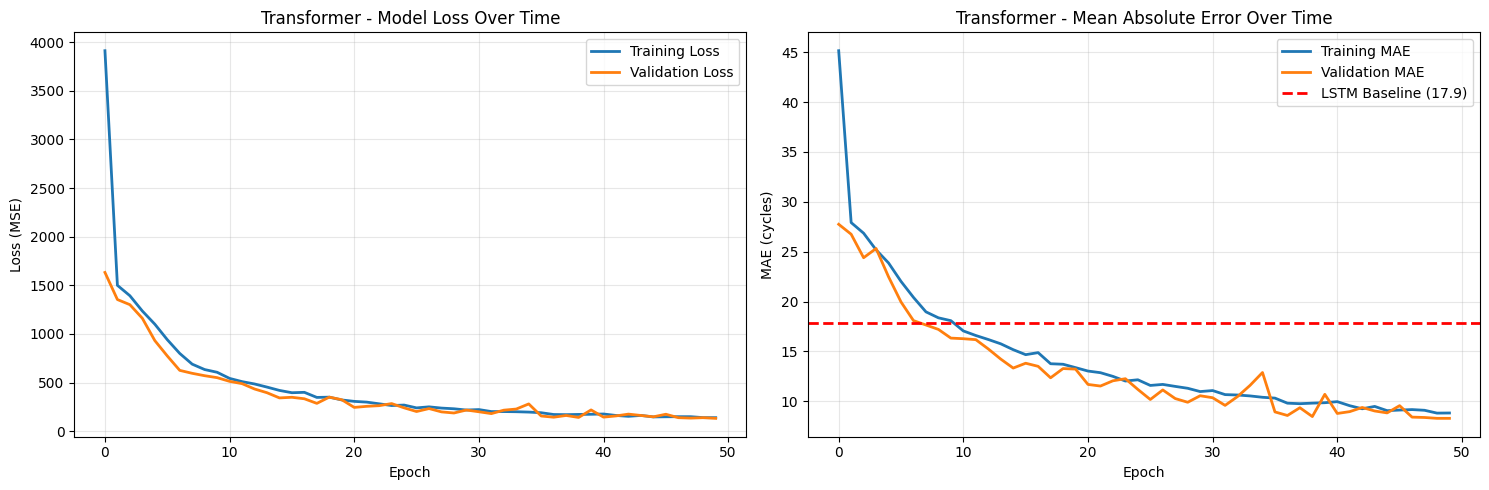

FINAL RESULTS COMPARISON
LSTM Baseline:      val_mae = 17.90 cycles
Transformer:        val_mae = 8.30 cycles
Improvement:        53.6% better!


In [4]:
# Plot training history comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history_transformer.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_transformer.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Transformer - Model Loss Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history_transformer.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history_transformer.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (cycles)')
axes[1].set_title('Transformer - Mean Absolute Error Over Time')
axes[1].axhline(y=17.9, color='r', linestyle='--', label='LSTM Baseline (17.9)', linewidth=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*60)
print("FINAL RESULTS COMPARISON")
print("="*60)
print(f"LSTM Baseline:      val_mae = 17.90 cycles")
print(f"Transformer:        val_mae = {min(history_transformer.history['val_mae']):.2f} cycles")
print(f"Improvement:        {((17.9 - min(history_transformer.history['val_mae']))/17.9)*100:.1f}% better!")
print("="*60)